In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

#files paths

DATA_DIR = Path("kg_output_csv")

files = {
    "nr1h3_neighbors": DATA_DIR / "nr1h3_top_neighbors.csv",
    "tyrobp_neighbors": DATA_DIR / "tyrobp_top_neighbors.csv",
    "nr1h3_paths": DATA_DIR / "nr1h3_shortest_path.csv",
    "tyrobp_paths": DATA_DIR / "tyrobp_shortest_path.csv",
    "neighbor_counts": DATA_DIR / "neighbor_counts.csv",
    "relationship_counts": DATA_DIR / "relationship_type_counts.csv",
}

#loading csv
dfs = {}

for name, path in files.items():
    dfs[name] = pd.read_csv(path)
    print(f"{name}: {dfs[name].shape[0]} rows, {dfs[name].shape[1]} columns")
    print(dfs[name].columns.tolist())
    print("-" * 60)

nr1h3_neighbors: 272 rows, 6 columns
['neighbor_type', 'neighbor', 'node_code', 'cui', 'relationship', 'source']
------------------------------------------------------------
tyrobp_neighbors: 152 rows, 6 columns
['neighbor_type', 'neighbor', 'node_code', 'cui', 'relationship', 'source']
------------------------------------------------------------
nr1h3_paths: 5 rows, 6 columns
['start', 'end', 'end_type', 'path_length', 'path_nodes', 'path_relationships']
------------------------------------------------------------
tyrobp_paths: 5 rows, 6 columns
['start', 'end', 'end_type', 'path_length', 'path_nodes', 'path_relationships']
------------------------------------------------------------
neighbor_counts: 8 rows, 3 columns
['gene', 'neighbor_type', 'count']
------------------------------------------------------------
relationship_counts: 30 rows, 4 columns
['gene', 'relationship', 'source', 'count']
------------------------------------------------------------


In [2]:
nr1h3_neighbors = dfs["nr1h3_neighbors"]
tyrobp_neighbors = dfs["tyrobp_neighbors"]
neighbor_counts = dfs["neighbor_counts"]
relationship_counts = dfs["relationship_counts"]
nr1h3_paths = dfs["nr1h3_paths"]
tyrobp_paths = dfs["tyrobp_paths"]

In [3]:
###preview neighbor files
display(nr1h3_neighbors.head(10))
display(tyrobp_neighbors.head(10))

,neighbor_type,neighbor,node_code,cui,relationship,source
0,[GO],Cell Differentiation process,0030154,C0007589,gene_plays_role_in_process,NCI
1,[Disease],Homeostasis,21979002,C0019868,gene_plays_role_in_process,NCI
2,[GO],pattern biosynthesis,0007389,C1160421,gene_plays_role_in_process,NCI
3,[GO],Steroid Metabolic Process,0008202,C0597520,gene_plays_role_in_process,NCI
4,[GO],microtubule/chromatin interaction,0003677,C1148673,gene_plays_role_in_process,NCI
5,[Disease],"Chromosomes, Human, Pair 11",16312006,C0008653,located_in,GENCODE
6,[Disease],pregnenolone,47350002,C0373704,negatively_correlated_with_chemical_or_drug,CMAP
7,[Compound],Methotrexate,126941,C0025677,negatively_correlated_with_chemical_or_drug,CMAP
8,[Compound],Trazodone,5533,C0040805,negatively_correlated_with_chemical_or_drug,CMAP
9,[Compound],Decitabine,451668,C0049065,negatively_correlated_with_chemical_or_drug,CMAP


,neighbor_type,neighbor,node_code,cui,relationship,source
0,[EFO],Neuropathy,3100,C4721453,associated_with,HGNCHPO
1,[Disease],Arthralgia,57676002,C0003862,associated_with,HGNCHPO
2,[Disease],Oculomotor apraxia,193662007,C3489733,associated_with,HGNCHPO
3,[Disease],Babinski Reflex,246586009,C0034935,associated_with,HGNCHPO
4,[Disease],Gait abnormality,22325002,C0575081,associated_with,HGNCHPO
5,[Disease],Physical aggression,248004009,C0424323,associated_with,HGNCHPO
6,[Disease],Autosomal recessive inheritance,258211005,C0441748,associated_with,HGNCHPO
7,[Disease],Bone pain,12584003,C0151825,associated_with,HGNCHPO
8,[Disease],Dementia,52448006,C0497327,associated_with,HGNCHPO
9,[Disease],"Reflex, Abnormal",46670006,C0034933,associated_with,HGNCHPO


In [4]:
###top neighbor types
display(neighbor_counts)

,gene,neighbor_type,count
0,NR1H3 gene,[Disease],176
1,NR1H3 gene,[Compound],86
2,NR1H3 gene,[GO],8
3,NR1H3 gene,[Protein],2
4,TYROBP gene,[Disease],102
5,TYROBP gene,[Compound],44
6,TYROBP gene,[EFO],4
7,TYROBP gene,[Protein],2


In [5]:
###relationship type counts
display(relationship_counts)

,gene,relationship,source,count
0,NR1H3 gene,negatively_correlated_with_chemical_or_drug,CMAP,111
1,NR1H3 gene,inverse_negatively_correlated_with_chemical_or...,CMAP,111
2,NR1H3 gene,positively_correlated_with_chemical_or_drug,CMAP,15
3,NR1H3 gene,inverse_positively_correlated_with_chemical_or...,CMAP,15
4,NR1H3 gene,gene_plays_role_in_process,NCI,5
5,NR1H3 gene,process_involves_gene,NCI,5
6,NR1H3 gene,negatively_regulates,LINCS,2
7,NR1H3 gene,negatively_regulated_by,LINCS,2
8,NR1H3 gene,located_in,GENCODE,1
9,NR1H3 gene,has_gene_product,UNIPROTKB,1


#### Top neightbors by source

In [6]:
###top sources for each gene
def source_summary(df, gene_name):
    print(f"\nTop sources for {gene_name}")
    
    summary = df["source"].value_counts().reset_index()
    summary.columns = ["source", "count"]
    
    display(summary.head(15))

source_summary(nr1h3_neighbors, "NR1H3")
source_summary(tyrobp_neighbors, "TYROBP")


Top sources for NR1H3


,source,count
0,CMAP,252
1,NCI,12
2,LINCS,4
3,GENCODE,2
4,UNIPROTKB,2



Top sources for TYROBP


,source,count
0,HGNCHPO,98
1,LINCS,44
2,NCI,2
3,GENCODE,2
4,CMAP,2
5,UNIPROTKB,2
6,ORDO,2


#### Top relationship types

In [7]:
#### Top relationship types
def relationship_summary(df, gene_name):
    print(f"\nTop relationship types for {gene_name}")
    
    summary = df["relationship"].value_counts().reset_index()
    summary.columns = ["relationship", "count"]
    
    display(summary.head(15))

relationship_summary(nr1h3_neighbors, "NR1H3")
relationship_summary(tyrobp_neighbors, "TYROBP")


Top relationship types for NR1H3


,relationship,count
0,negatively_correlated_with_chemical_or_drug,111
1,inverse_negatively_correlated_with_chemical_or...,111
2,positively_correlated_with_chemical_or_drug,15
3,inverse_positively_correlated_with_chemical_or...,15
4,gene_plays_role_in_process,5
5,process_involves_gene,5
6,negatively_regulates,2
7,negatively_regulated_by,2
8,located_in,1
9,has_gene_product,1



Top relationship types for TYROBP


,relationship,count
0,associated_with,49
1,inverse_associated_with,49
2,positively_regulates,12
3,positively_regulated_by,12
4,negatively_regulates,10
5,negatively_regulated_by,10
6,gene_plays_role_in_process,1
7,located_in,1
8,positively_correlated_with_chemical_or_drug,1
9,inverse_positively_correlated_with_chemical_or...,1


#### Find important neighbors

In [8]:
####important neighbors
keywords = [
    "apoe", "abca1", "trem2", "alzheimer", "amyloid",
    "cholesterol", "lipid", "microglia", "immune", "inflammation",
    "apolipoprotein", "cholesterol", "sterol", "lipoprotein", "hdl",
    "inflammatory", "immune", "microglial", "macrophage",
    "amyloid", "dementia", "neuro"
]
def find_keywords(df, gene_name):
    print(f"\nRelevant neighbors for {gene_name}")
    pattern = "|".join(keywords)
    hits = df[df["neighbor"].str.lower().str.contains(pattern, na=False)]
    display(hits)
find_keywords(nr1h3_neighbors, "NR1H3")
find_keywords(tyrobp_neighbors, "TYROBP")


Relevant neighbors for NR1H3


,neighbor_type,neighbor,node_code,cui,relationship,source
260,[Protein],Oxysterols receptor LXR-alpha,Q13133,UNIPROTKB:Q13133 CUI,has_gene_product,UNIPROTKB
271,[Protein],Oxysterols receptor LXR-alpha,Q13133,UNIPROTKB:Q13133 CUI,gene_product_of,UNIPROTKB



Relevant neighbors for TYROBP


,neighbor_type,neighbor,node_code,cui,relationship,source
0,[EFO],Neuropathy,3100,C4721453,associated_with,HGNCHPO
8,[Disease],Dementia,52448006,C0497327,associated_with,HGNCHPO
44,[Disease],Dementia of frontal lobe type,278857002,C0338455,associated_with,HGNCHPO
77,[EFO],Neuropathy,3100,C4721453,inverse_associated_with,HGNCHPO
103,[Disease],Dementia,52448006,C0497327,inverse_associated_with,HGNCHPO
117,[Disease],Dementia of frontal lobe type,278857002,C0338455,inverse_associated_with,HGNCHPO


#### Shortest path from NR1H3/TYROBP to ABCA1/APOE/TREM2/AD

In [9]:
####shortest path summaries
print("NR1H3 shortest paths")
display(nr1h3_paths)
print("TYROBP shortest paths")
display(tyrobp_paths)

NR1H3 shortest paths


,start,end,end_type,path_length,path_nodes,path_relationships
0,NR1H3 gene,ABCA1 gene,[Gene],2,"[NR1H3 gene, pregnenolone, ABCA1 gene]","[negatively_correlated_with_chemical_or_drug, ..."
1,NR1H3 gene,APOE gene,[Gene],2,"[NR1H3 gene, Trazodone, APOE gene]","[negatively_correlated_with_chemical_or_drug, ..."
2,NR1H3 gene,APOE gene,[Disease],2,"[NR1H3 gene, Trazodone, APOE gene]","[negatively_correlated_with_chemical_or_drug, ..."
3,NR1H3 gene,TREM2 gene,[Gene],2,"[NR1H3 gene, Amphotericin B, TREM2 gene]","[negatively_correlated_with_chemical_or_drug, ..."
4,NR1H3 gene,Alzheimer's Disease,[Disease],3,"[NR1H3 gene, Homo sapiens, MIR29A gene, Alzhei...","[organism_has_gene, organism_has_gene, gene_as..."


TYROBP shortest paths


,start,end,end_type,path_length,path_nodes,path_relationships
0,TYROBP gene,ABCA1 gene,[Gene],2,"[TYROBP gene, Neuropathy, ABCA1 gene]","[associated_with, associated_with]"
1,TYROBP gene,APOE gene,[Gene],2,"[TYROBP gene, Urogenital Diseases, APOE gene]","[associated_with, associated_with]"
2,TYROBP gene,TREM2 gene,[Gene],2,"[TYROBP gene, Hereditary Chorea, TREM2 gene]","[associated_with, associated_with]"
3,TYROBP gene,Alzheimer's Disease,[Disease],3,"[TYROBP gene, Movement Disorders, central nerv...","[associated_with, PAR, PAR]"
4,TYROBP gene,APOE gene,[Disease],3,"[TYROBP gene, Deformity of lower limb, CTH gen...","[associated_with, associated_with, coexpressio..."


#### Simple bar charts

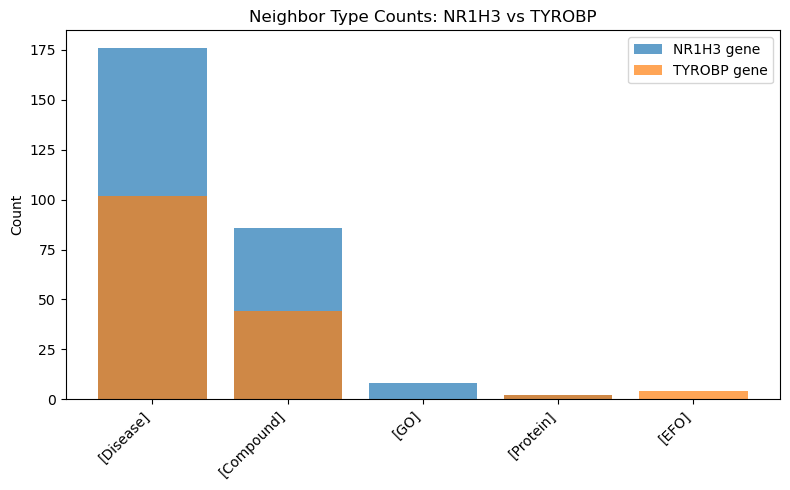

In [10]:
#### neighbor type bar chart

plt.figure(figsize=(8, 5))
for gene in neighbor_counts["gene"].unique():
    temp = neighbor_counts[neighbor_counts["gene"] == gene]
    plt.bar(temp["neighbor_type"].astype(str), temp["count"], label=gene, alpha=0.7)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Neighbor Type Counts: NR1H3 vs TYROBP")
plt.legend()
plt.tight_layout()
plt.savefig("neighbor_type_counts.png", dpi=300)
plt.show()

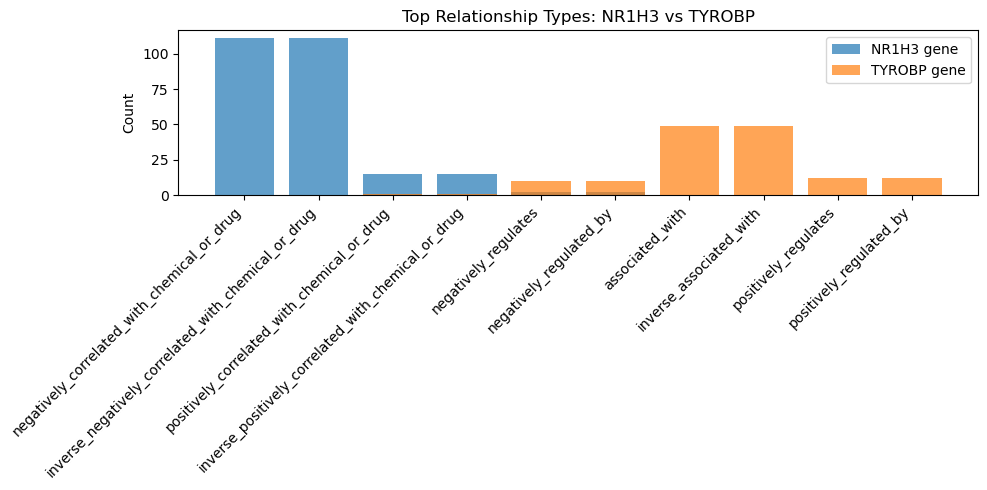

In [11]:
####relationship count chart
top_rel = relationship_counts.groupby("relationship")["count"].sum().sort_values(ascending=False).head(10).index
plot_df = relationship_counts[relationship_counts["relationship"].isin(top_rel)]

plt.figure(figsize=(10, 5))
for gene in plot_df["gene"].unique():
    temp = plot_df[plot_df["gene"] == gene]
    plt.bar(temp["relationship"], temp["count"], label=gene, alpha=0.7)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Top Relationship Types: NR1H3 vs TYROBP")
plt.legend()
plt.tight_layout()
plt.savefig("relationship_type_counts.png", dpi=300)
plt.show()

#### Small network graph

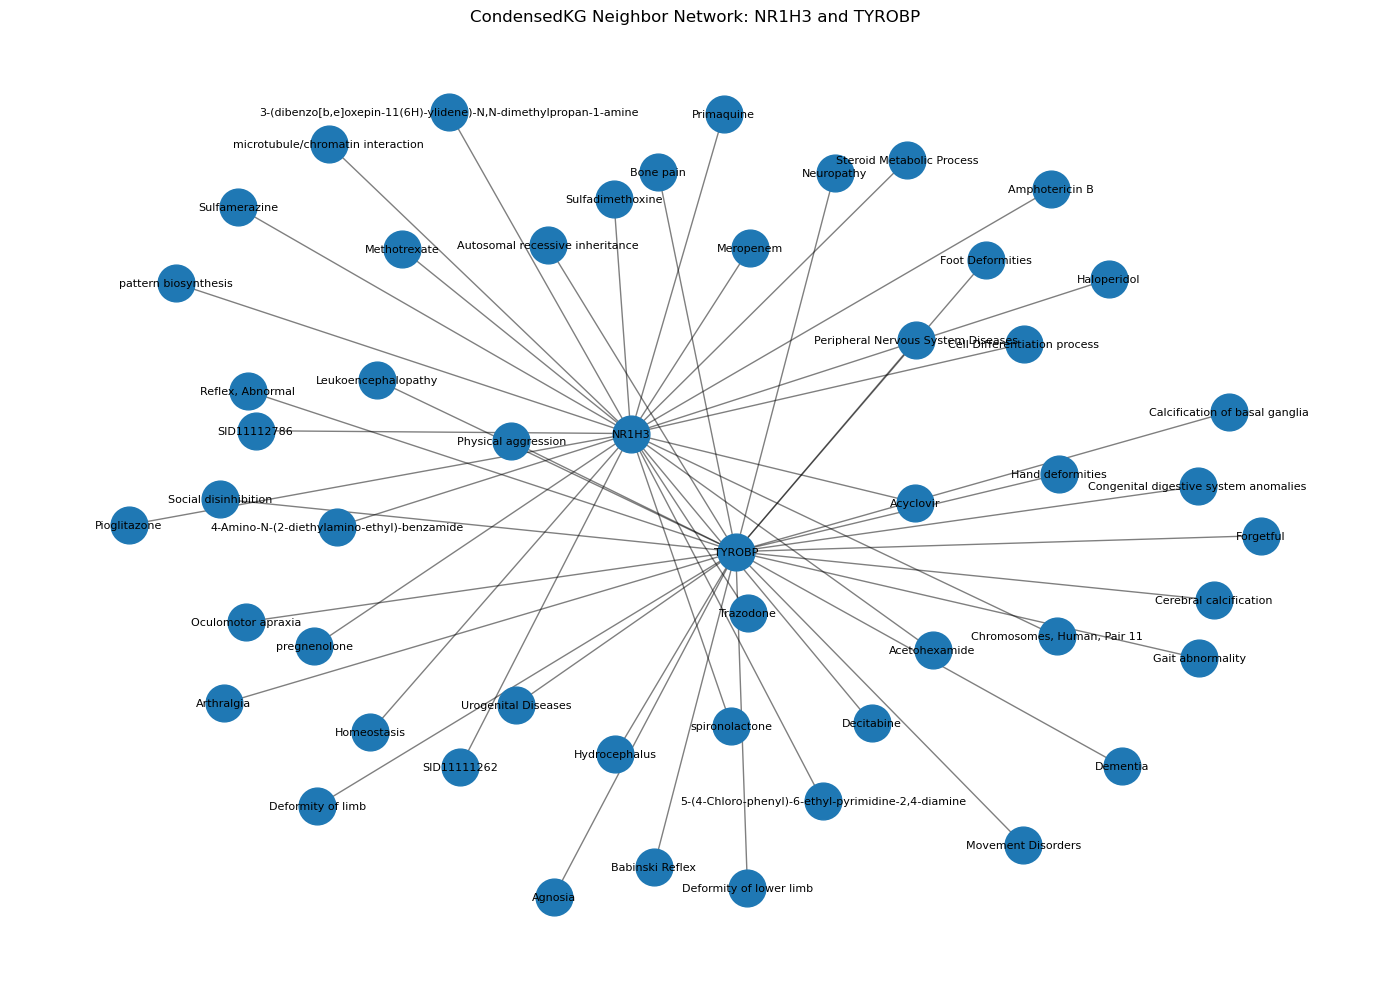

In [12]:
#take top 25 neighbors as returned by the KG query(no weight) todo
def build_network(df, gene_name, max_neighbors=25):
    G = nx.Graph()
    G.add_node(gene_name)

    top_df = df.head(max_neighbors)

    for _, row in top_df.iterrows():
        neighbor = row["neighbor"]
        relationship = row["relationship"]

        G.add_node(neighbor)
        G.add_edge(gene_name, neighbor, relationship=relationship)

    return G

G1 = build_network(nr1h3_neighbors, "NR1H3", max_neighbors=25)
G2 = build_network(tyrobp_neighbors, "TYROBP", max_neighbors=25)

G = nx.compose(G1, G2)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.8)

nx.draw_networkx_nodes(G, pos, node_size=700)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("CondensedKG Neighbor Network: NR1H3 and TYROBP")
plt.axis("off")
plt.tight_layout()
plt.savefig("nr1h3_tyrobp_network.png", dpi=300)
plt.show()